# Which Content Pages Should Be Reviewed First?
## A leakage-safe framework for future performance risk and human review

**Nicholas Perikli · FlyRank ML Internship capstone**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NiknaxTheGreek/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

### Abstract

This FlyRank case study investigates whether information available before a content-review decision can identify pages at risk of future search-performance decline and, more importantly, determine which pages should receive limited human attention first. From the pseudonymized FlyRank internship warehouse, a balanced proof-of-concept cohort of 2,520 pages across 21 clients was constructed through exposure-based stratification, while candidate predictors were grouped by behavioral role and reduced to five leakage-safe March 2026 features—`aggregate_ctr`, `median_position`, `position_slope_per_day`, `position_iqr`, and `content_age_days`—without using April outcomes for selection. Classification estimates whether future decline occurs, signed regression estimates the direction and magnitude of future impression change, and negative predicted change is converted to decline severity and combined with classification risk to rank a top-50 review queue; independent CTR and freshness diagnostics then attach transparent reason codes and rule-based action archetypes so a reviewer can understand why a page was surfaced. The pipeline showed useful signal during development validation that kept clients separated, but a six-client stress test exposed limited transfer: regression retained a modest improvement over its frozen baseline, while classification and the final ranking did not. For FlyRank's applied search-intelligence problem—deciding which pages in large content inventories deserve limited human review first—the contribution is therefore a human-review decision-support framework, not an automated intervention system, that connects risk estimation, change estimation, prioritization and diagnostic guidance while requiring fresh client-level validation before broader operational use.

### Introduction / problem statement

In FlyRank's applied search-intelligence setting, large content inventories create an allocation problem before they create a modeling problem: a content or SEO team cannot inspect every page, so it needs a defensible way to decide **what deserves attention first**. A binary decline flag alone is not enough because it does not say how large the expected change is, how pages should be ordered under limited review capacity, or why a surfaced page deserves investigation.

The project therefore decomposes the decision into a progression of standard analytical tasks. First, transparent grouping and stratification make the modeling population comparable and prevent large clients or exposure levels from dominating the proof of concept. Next, classification estimates **whether** a future decline occurs and signed regression estimates **how much and in which direction** performance changes; negative predicted change is then converted to decline severity and combined with decline risk to produce the final ranking.

The ranked queue is only useful if a human can interpret it. Independent CTR-relative-to-position and freshness signals are therefore attached after ranking as reason codes and rule-based diagnostic archetypes, turning a score into a review starting point without claiming that the suggested action will cause recovery.

A transparent baseline is retained throughout because the learned system is only useful where it improves the decision under an honest validation design. The project therefore preserves negative results, separates development evidence from unseen-client stress testing, and treats automation as out of scope.

## 1. Question

### Research question

Can search-performance and content signals available before a fixed decision point be used to identify pages at risk of future performance decline and produce a useful ranked queue for human content review?

### Decision supported

The project supports a practical allocation decision: when a content, SEO or marketing team cannot inspect every page, which pages should enter a limited human-review queue first?

The intended product is therefore **decision support**, not automated content intervention. A reviewer receives a ranked queue with model risk, reason codes and a suggested diagnostic starting point, then decides whether any intervention is appropriate.

### Unit of analysis

One modeling row represents one pseudonymized content page at a fixed decision point. Predictors use information available by **31 March 2026**; the future outcome is observed during **April 2026** for that same page.

### Why the problem needs a baseline

A more complex model is only useful if it improves on a transparent rule under an honest validation design. For this reason the project freezes classification, regression and ranking baselines before model comparison, and treats **Precision@50** as the primary project metric because the operational output is a limited review queue.

The paper does not assume that ML must win. Negative or mixed out-of-sample results are retained as findings.

In [1]:
from pathlib import Path
import json
import pandas as pd

def repo_path(relative_path):
    """Resolve a repository-relative path whether run from repo root or notebook folder."""
    relative_path = Path(relative_path)
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidate = base / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not resolve repository path: {relative_path}")

with open(repo_path("work/outputs/assignment8_action_playbook_metrics.json"), "r", encoding="utf-8") as fh:
    playbook_receipt = json.load(fh)

question_contract = pd.DataFrame([
    {
        "item": "decision",
        "value": playbook_receipt["intended_use_and_limits"]["supported_decision"],
    },
    {
        "item": "intended_user",
        "value": playbook_receipt["intended_use_and_limits"]["intended_user"],
    },
    {
        "item": "operating_mode",
        "value": playbook_receipt["intended_use_and_limits"]["operating_mode"],
    },
    {
        "item": "final_decision_maker",
        "value": playbook_receipt["human_review_policy"]["final_decision_maker"],
    },
])

assert playbook_receipt["guardrails"]["human_review_required_for_every_row"] is True
assert playbook_receipt["guardrails"]["automatic_edit_or_publish_allowed"] is False
assert playbook_receipt["human_review_policy"]["final_decision_maker"] == "human_reviewer"

display(question_contract)
print("Question/decision contract verified from Assignment 8 receipts.")

,item,value
0,decision,prioritize a top-50 human-review queue and cho...
1,intended_user,content / SEO analyst or editor
2,operating_mode,research POC / human decision-support only
3,final_decision_maker,human_reviewer


Question/decision contract verified from Assignment 8 receipts.


## 2. Data

### Release and source

The analysis uses the pseudonymized **FlyRank internship warehouse** release, build `flyrank_pseudonymized_warehouse_release_v20260703`, exported on 3 July 2026 from the central data warehouse. The release documentation records **78,835,655 rows** in `fact_content_daily_performance`, whose grain is one daily content-performance observation per client and content item.

That figure describes the **warehouse scale**. It is not the model-training row count.

### Tables used

The final modeling contract uses:

- `fact_content_daily_performance` for March predictor construction and April outcome observations;
- `dim_content` for page creation date and therefore `content_age_days`;
- `dim_clients` for context only.

The fixed `fact_content_query_90d` table is deliberately excluded because its trailing window can overlap the future outcome period.

### Time windows

The decision cutoff is **31 March 2026**.

- Feature window: **1–31 March 2026**
- Outcome window: **1–30 April 2026**
- Minimum observability: at least **20 usable GSC days** in both months for an evaluable page.

The outcome compares average impressions per usable day rather than raw monthly totals so that the 31-day March window and 30-day April window are comparable.

### Final proof-of-concept population

The locked POC contains **2,520 pages from 21 pseudonymized clients**. To stop large clients or high-exposure pages from dominating, the sample is deliberately balanced:

- 840 Low-exposure pages;
- 840 Medium-exposure pages;
- 840 High-exposure pages.

This balancing improves the proof-of-concept comparison but changes the natural population mix. Therefore prevalence, calibration and aggregate rates from the 2,520-page sample must **not** be presented as natural FlyRank-wide prevalence.

### Observability and exclusions

The later audit found 106,546 March feature-eligible pages across 37 clients, of which 95,633 pages had sufficient April observability. That is **89.76%** of March-eligible pages.

The active contract excludes identifiers as predictive features, GA4 features because coverage is too sparse, absolute exposure as a predictor because exposure was already used for sampling strata, query-90d fields because of future-window risk, and mutable snapshot fields whose March-end value cannot be guaranteed.

All public reporting remains aggregate and pseudonymized; no client names, domains, URLs, page titles, keywords or raw search queries are exposed.

In [2]:
with open(repo_path("work/outputs/assignment7_leakage_audit.json"), "r", encoding="utf-8") as fh:
    leakage_audit = json.load(fh)

with open(repo_path("work/outputs/baseline_split_manifest.json"), "r", encoding="utf-8") as fh:
    split_manifest = json.load(fh)

guide_text = repo_path("docs/ml-intern-dataset-and-lane-guide.md").read_text(encoding="utf-8")

release_checks = {
    "warehouse_build_id_present": "flyrank_pseudonymized_warehouse_release_v20260703" in guide_text,
    "daily_fact_row_count_present": "78,835,655" in guide_text,
    "daily_fact_end_date_present": "2026-06-30" in guide_text,
}

population = leakage_audit["population_selection"]
data_summary = pd.DataFrame([
    {"measure": "POC pages", "value": split_manifest["population_pages"]},
    {"measure": "POC clients", "value": split_manifest["population_clients"]},
    {"measure": "March feature-eligible pages", "value": population["march_feature_eligible_pages"]},
    {"measure": "April-observable pages", "value": population["april_observable_pages"]},
    {
        "measure": "Outcome-observable share (%)",
        "value": round(population["pct_march_pages_retained_for_observable_outcome"], 2),
    },
])

assert all(release_checks.values()), release_checks
assert split_manifest["population_pages"] == 2520
assert split_manifest["population_clients"] == 21
assert split_manifest["train_pages"] + split_manifest["test_pages"] == 2520
assert split_manifest["client_overlap"] == []

display(data_summary)
print("Release metadata checks:", release_checks)
print("Balanced POC and observability contract verified.")

,measure,value
0,POC pages,2520.00
1,POC clients,21.00
2,March feature-eligible pages,106546.00
3,April-observable pages,95633.00
4,Outcome-observable share (%),89.76


Release metadata checks: {'warehouse_build_id_present': True, 'daily_fact_row_count_present': True, 'daily_fact_end_date_present': True}
Balanced POC and observability contract verified.


## 3. Methodology

### Target and task structure

The executed methodology follows one decision chain:

**exposure-based population stratification → five-feature reduction → classification + signed-change regression → risk-severity ranking → diagnostic reason codes / action archetypes → human review.**

**Classification** asks whether the page declines in the future:

`future_decline = 1 if future_impression_change < 0 else 0`

**Regression** estimates the signed future relative change:

`future_impression_change = (April avg impressions/day - March avg impressions/day) / March avg impressions/day`

Negative regression predictions are converted into non-negative predicted decline severity; positive predicted change contributes zero decline severity.

**Ranking** combines predicted decline risk and predicted decline severity to prioritize a fixed top-50 review queue. The tuned scoring form is:

`p_decline^gamma × (1 + lambda × normalized_predicted_decline_severity)`

with `gamma = 2` and `lambda = 1`.

The target is constructed only after the March feature set has been fixed.

### Five-feature contract

The final model uses exactly five features, all knowable by the decision cutoff:

1. **`aggregate_ctr`** — March click efficiency;
2. **`median_position`** — typical March search position;
3. **`position_slope_per_day`** — March rank movement;
4. **`position_iqr`** — March rank stability/volatility;
5. **`content_age_days`** — lifecycle age measured at 31 March 2026.

Feature selection is intentionally simple and target-blind: candidate variables were grouped into behavioral families, obvious duplicates and unsafe fields were removed using coverage, interpretability and within-family redundancy, and April outcomes were not used to choose the five predictors.

### Frozen baselines

Three baselines were fixed before learned-model comparison:

- **Classification:** training-set decline prior / majority-class prediction;
- **Regression:** training-set mean future change;
- **Ranking:** a transparent low-CTR-for-position rule with a staleness boost.

All learned models are compared with their corresponding baseline on the same evaluation population and metric.

### Validation design

The 2,520-page POC is split by client using `GroupShuffleSplit(test_size=0.25, random_state=42)`:

- development side: **1,800 pages from 15 clients**;
- six-client stress-test side: **720 pages from 6 clients**;
- client overlap: **zero**.

Model and hyperparameter selection occur only on the 15 development clients using **5-fold client-grouped cross-validation**. The six held-out clients are then used as a transfer/generalization stress test and are not used to select the model in the final modeling protocol. Because this subset had been inspected during earlier project development, it is **not** presented as pristine or never-before-seen confirmatory evidence; its role is a client-separated stress test of transfer under distribution shift.

This distinction is central to the paper: grouped development-CV performance and six-client stress-test performance are reported separately.

### Model families

The selected classifier is a **Random Forest classifier**. The selected regressor is a **Random Forest regressor**. Ranking is a tuned risk-severity blend using their outputs.

The project metric contract is:

- classification: ROC-AUC primary; Precision, Recall and F1 secondary;
- regression: RMSE primary; MAE, Median Absolute Error and R² secondary;
- ranking: Precision@50 primary; Recall@50, Lift@50 and NDCG@50 secondary.

### Leakage controls

Every active feature was audited for availability by 31 March 2026, target derivation, future overlap, decision derivation and identifier leakage. All five passed, with no forbidden-feature overlap.

A deliberate leakage experiment demonstrates why this matters. When an exact copy of the future outcome was added as an illegal feature, grouped-holdout regression R² jumped from **-0.142 to 1.000**. A second target-derived classification leakage test increased grouped-CV ROC-AUC from **0.665 to 1.000**. The illegal fields were then removed.

These experiments are diagnostics, not model results; they show how future information can make a weak analysis look artificially perfect.

### Assumptions and interpretation boundary

This is observational prediction and prioritization, not an intervention study. The analysis can support statements about measured associations, out-of-sample ranking performance under the tested splits, and which pages merit review. It does not establish that refreshing a page, changing a title or improving CTR will cause a performance recovery.

In [3]:
with open(repo_path("work/outputs/assignment6_model_benchmark.json"), "r", encoding="utf-8") as fh:
    model_benchmark = json.load(fh)

active_features = leakage_audit["active_features"]
expected_features = [
    "aggregate_ctr",
    "median_position",
    "position_slope_per_day",
    "position_iqr",
    "content_age_days",
]

method_checks = {
    "five_features_exact": active_features == expected_features,
    "no_forbidden_overlap": leakage_audit["forbidden_feature_overlap"] == [],
    "zero_client_overlap": split_manifest["client_overlap"] == [],
    "development_clients": split_manifest["train_clients"] and len(split_manifest["train_clients"]) == 15,
    "stress_test_clients": split_manifest["test_clients"] and len(split_manifest["test_clients"]) == 6,
    "ranking_k_50": split_manifest["ranking_k"] == 50,
    "ranking_gamma_2": model_benchmark["ranking"]["model"]["gamma"] == 2,
    "ranking_lambda_1": model_benchmark["ranking"]["model"]["lambda"] == 1,
}

assert all(method_checks.values()), method_checks
assert all(row["verdict"] == "PASS" for row in leakage_audit["feature_audit"])
assert leakage_audit["deliberate_leakage_test"]["illegal_target_derived_feature_grouped_cv_roc_auc"] == 1

method_summary = pd.DataFrame([
    {"component": "Classification", "selected_method": model_benchmark["classification"]["model"]["name"], "primary_metric": "ROC-AUC"},
    {"component": "Regression", "selected_method": model_benchmark["regression"]["model"]["name"], "primary_metric": "RMSE"},
    {"component": "Ranking", "selected_method": model_benchmark["ranking"]["model"]["name"], "primary_metric": "Precision@50"},
])

display(method_summary)
print("Active features:", active_features)
print("Methodology checks:", method_checks)
print(
    "Leakage demonstration ROC-AUC:",
    round(leakage_audit["deliberate_leakage_test"]["legal_grouped_cv_roc_auc"], 3),
    "->",
    round(leakage_audit["deliberate_leakage_test"]["illegal_target_derived_feature_grouped_cv_roc_auc"], 3),
)

,component,selected_method,primary_metric
0,Classification,RandomForestClassifier,ROC-AUC
1,Regression,RandomForestRegressor,RMSE
2,Ranking,grouped_cv_tuned_risk_severity_blend,Precision@50


Active features: ['aggregate_ctr', 'median_position', 'position_slope_per_day', 'position_iqr', 'content_age_days']
Methodology checks: {'five_features_exact': True, 'no_forbidden_overlap': True, 'zero_client_overlap': True, 'development_clients': True, 'stress_test_clients': True, 'ranking_k_50': True, 'ranking_gamma_2': True, 'ranking_lambda_1': True}
Leakage demonstration ROC-AUC: 0.665 -> 1.0


## 4. Results — model vs baseline

The results are reported in two layers because they answer different questions.

### 4.1 Grouped development validation

Model selection and tuning used five-fold client-grouped cross-validation on the **15 development clients only**. Under that design, the learned components improved on their frozen baselines for all three benchmarked tasks:

| Task | Metric | CV baseline | Learned CV | Reading |
|---|---:|---:|---:|---|
| Classification | ROC-AUC | 0.500 | **0.665** | better discrimination during grouped development CV |
| Regression | RMSE ↓ | 0.852 | **0.806** | lower error during grouped development CV |
| Ranking | Precision@50 | 0.824 | **0.872** | higher top-50 precision during grouped development CV |

These values are **development evidence**, not final unseen-client performance.

### 4.2 Six-client stress test

The selected models were evaluated on the client-separated stress-test set of **720 pages from 6 clients that did not appear in model selection**. This subset had been inspected during earlier project development, so it is treated as a transfer stress test rather than pristine final confirmation.

| Task | Metric | Frozen baseline | Learned model | Reading |
|---|---:|---:|---:|---|
| Classification | ROC-AUC | **0.500** | 0.494 | did not beat the prior-probability baseline |
| Regression | RMSE ↓ | 1.431 | **1.379** | slightly lower error than the mean baseline |
| Ranking | Precision@50 | **0.480** | 0.360 | underperformed the transparent ranking rule |

The stress test therefore changes the interpretation materially. The system showed promising grouped-development performance, but that improvement did **not** transfer consistently to unseen clients.

The regression component retained a modest RMSE improvement. The classifier was essentially at chance-level discrimination on the six-client stress test, and the learned top-50 ranking contained **18 true future declines and 32 false picks**, compared with a frozen rule baseline Precision@50 of 0.48.

### 4.3 Validation-design audit

Assignment 7 compared a naive random-page CV with client-grouped CV on the development population.

- random-page classification ROC-AUC: **0.725**
- grouped-client classification ROC-AUC: **0.665**
- random-page ranking Precision@50: **0.948**
- grouped-client ranking Precision@50: **0.872**

Random-page validation allowed the same 15 clients to appear on both sides of every fold; grouped validation reduced that overlap to zero. The more optimistic random-page classification/ranking results therefore illustrate why client separation matters.

### Result interpretation

The headline finding is not that the model universally outperformed the rule baseline. It is that **performance was validation-sensitive**. The learned system looked useful during client-grouped development validation, but the six-client stress test exposed a transfer problem—especially for the primary product metric, Precision@50.

For this reason the downstream action playbook is framed as a **guarded human-review POC**, and fresh validation is required before operational use on materially new client populations.

,validation_layer,task,metric,baseline,learned,learned_beats_baseline
0,Grouped development CV,Classification,ROC-AUC,0.5000,0.6650,True
1,Grouped development CV,Regression,RMSE,0.8515,0.8063,True
2,Grouped development CV,Ranking,Precision@50,0.8240,0.8720,True
3,Six-client stress test,Classification,ROC-AUC,0.5000,0.4942,False
4,Six-client stress test,Regression,RMSE,1.4311,1.3791,True
5,Six-client stress test,Ranking,Precision@50,0.4800,0.3600,False



Validation-design audit:


,metric,random_page_cv,client_grouped_cv
0,Classification ROC-AUC,0.7247,0.6650
1,Regression RMSE,0.8186,0.8063
2,Ranking Precision@50,0.9480,0.8720


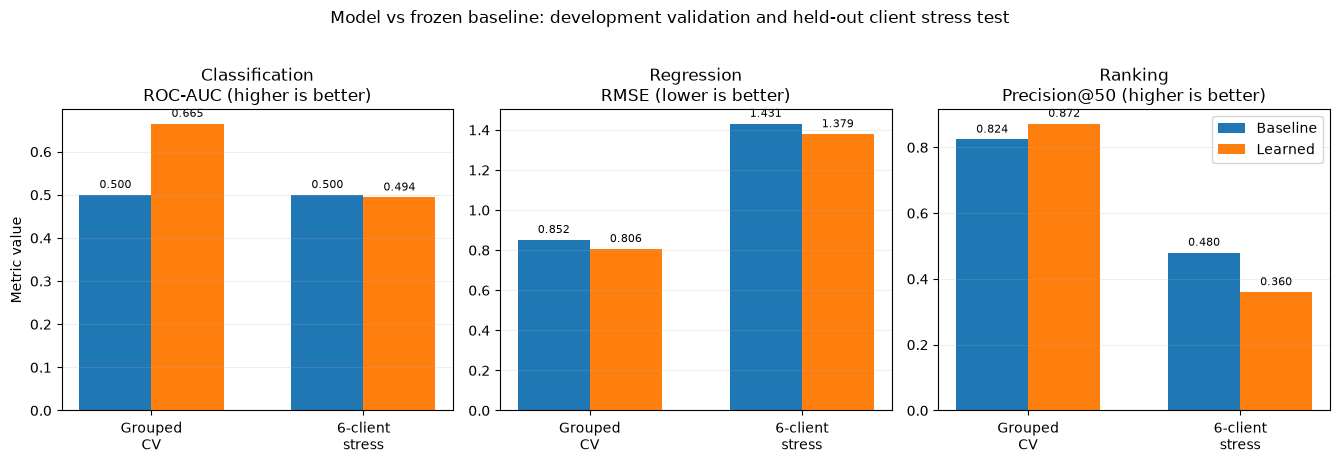


Saved paper figure: /home/runner/work/flyrank-ml-internship/flyrank-ml-internship/work/figures/capstone_model_vs_baseline.png
Stress-test truth preserved: classification=False, regression=True, ranking=False


In [4]:
import matplotlib.pyplot as plt
import numpy as np

with open(repo_path("work/outputs/assignment6_model_benchmark.json"), "r", encoding="utf-8") as fh:
    benchmark = json.load(fh)

with open(repo_path("work/outputs/assignment7_split_audit.json"), "r", encoding="utf-8") as fh:
    split_audit = json.load(fh)

with open(repo_path("work/outputs/assignment6_error_audit.json"), "r", encoding="utf-8") as fh:
    error_audit = json.load(fh)

# Exact paper table: development CV and held-out six-client stress test.
results_table = pd.DataFrame([
    {
        "validation_layer": "Grouped development CV",
        "task": "Classification",
        "metric": "ROC-AUC",
        "baseline": benchmark["cv_baselines"]["summary"]["classification"]["mean"],
        "learned": benchmark["classification"]["model"]["grouped_cv_roc_auc"],
        "better_direction": "higher",
    },
    {
        "validation_layer": "Grouped development CV",
        "task": "Regression",
        "metric": "RMSE",
        "baseline": benchmark["cv_baselines"]["summary"]["regression"]["mean"],
        "learned": benchmark["regression"]["model"]["grouped_cv_rmse"],
        "better_direction": "lower",
    },
    {
        "validation_layer": "Grouped development CV",
        "task": "Ranking",
        "metric": "Precision@50",
        "baseline": benchmark["cv_baselines"]["summary"]["ranking"]["mean"],
        "learned": benchmark["ranking"]["model"]["grouped_cv_precision_at_50"],
        "better_direction": "higher",
    },
    {
        "validation_layer": "Six-client stress test",
        "task": "Classification",
        "metric": "ROC-AUC",
        "baseline": benchmark["classification"]["baseline"]["roc_auc"],
        "learned": benchmark["classification"]["model"]["roc_auc"],
        "better_direction": "higher",
    },
    {
        "validation_layer": "Six-client stress test",
        "task": "Regression",
        "metric": "RMSE",
        "baseline": benchmark["regression"]["baseline"]["rmse"],
        "learned": benchmark["regression"]["model"]["rmse"],
        "better_direction": "lower",
    },
    {
        "validation_layer": "Six-client stress test",
        "task": "Ranking",
        "metric": "Precision@50",
        "baseline": benchmark["ranking"]["baseline"]["precision_at_50"],
        "learned": benchmark["ranking"]["model"]["precision_at_50"],
        "better_direction": "higher",
    },
])

def beats_baseline(row):
    if row["better_direction"] == "higher":
        return row["learned"] > row["baseline"]
    return row["learned"] < row["baseline"]

results_table["learned_beats_baseline"] = results_table.apply(beats_baseline, axis=1)

display(
    results_table[
        ["validation_layer", "task", "metric", "baseline", "learned", "learned_beats_baseline"]
    ].round(4)
)

# Validation audit summary: random-page CV vs honest client-grouped CV.
split_summary = pd.DataFrame(split_audit["summary"]).set_index("split")
validation_audit_table = pd.DataFrame([
    {
        "metric": "Classification ROC-AUC",
        "random_page_cv": split_summary.loc["random_page_cv", "classification_roc_auc"],
        "client_grouped_cv": split_summary.loc["grouped_client_cv", "classification_roc_auc"],
    },
    {
        "metric": "Regression RMSE",
        "random_page_cv": split_summary.loc["random_page_cv", "regression_rmse"],
        "client_grouped_cv": split_summary.loc["grouped_client_cv", "regression_rmse"],
    },
    {
        "metric": "Ranking Precision@50",
        "random_page_cv": split_summary.loc["random_page_cv", "ranking_precision_at_50"],
        "client_grouped_cv": split_summary.loc["grouped_client_cv", "ranking_precision_at_50"],
    },
])

print("\nValidation-design audit:")
display(validation_audit_table.round(4))

# Core assertions: paper must preserve the unfavorable stress-test findings.
stress = results_table[results_table["validation_layer"] == "Six-client stress test"]
assert bool(
    stress.loc[stress["task"] == "Classification", "learned_beats_baseline"].iloc[0]
) is False
assert bool(
    stress.loc[stress["task"] == "Regression", "learned_beats_baseline"].iloc[0]
) is True
assert bool(
    stress.loc[stress["task"] == "Ranking", "learned_beats_baseline"].iloc[0]
) is False

assert error_audit["ranking"]["top50_true_declines"] == 18
assert error_audit["ranking"]["top50_false_picks"] == 32
assert split_summary.loc["random_page_cv", "mean_client_overlap"] == 15
assert split_summary.loc["grouped_client_cv", "mean_client_overlap"] == 0

# Paper-ready comparison figure.
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.5))

tasks = [
    ("Classification", "ROC-AUC", "higher is better"),
    ("Regression", "RMSE", "lower is better"),
    ("Ranking", "Precision@50", "higher is better"),
]

for ax, (task, metric, direction_note) in zip(axes, tasks):
    task_rows = results_table[results_table["task"] == task]
    dev = task_rows[task_rows["validation_layer"] == "Grouped development CV"].iloc[0]
    stress_row = task_rows[task_rows["validation_layer"] == "Six-client stress test"].iloc[0]

    x = np.array([0, 1])
    width = 0.34
    baseline_vals = [dev["baseline"], stress_row["baseline"]]
    learned_vals = [dev["learned"], stress_row["learned"]]

    b1 = ax.bar(x - width/2, baseline_vals, width, label="Baseline")
    b2 = ax.bar(x + width/2, learned_vals, width, label="Learned")

    ax.set_xticks(x)
    ax.set_xticklabels(["Grouped\nCV", "6-client\nstress"])
    ax.set_title(f"{task}\n{metric} ({direction_note})")
    ax.grid(axis="y", alpha=0.2)

    for bars in [b1, b2]:
        ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)

axes[0].set_ylabel("Metric value")
axes[2].legend(loc="best")
fig.suptitle("Model vs frozen baseline: development validation and held-out client stress test", y=1.02)
fig.tight_layout()

figures_dir = repo_path("work/figures")
figures_dir.mkdir(parents=True, exist_ok=True)
figure_path = figures_dir / "capstone_model_vs_baseline.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"\nSaved paper figure: {figure_path}")
print("Stress-test truth preserved: classification=False, regression=True, ranking=False")

## 5. Limitations & honest framing

The main limitation is not model complexity; it is **transfer to unseen clients**. Grouped development validation was promising, but the six-client stress test did not reproduce the same gains. Classification ROC-AUC fell from 0.665 in grouped development CV to 0.494 on the held-out clients, while ranking Precision@50 fell from 0.872 to 0.360 and below the frozen rule baseline of 0.480. The project therefore does not support a claim of reliable cross-client generalization.

### 5.1 Balanced proof-of-concept sample

The final sample is deliberately balanced across 21 clients and three exposure tiers. This prevents a few large clients or high-exposure pages from dominating the analysis, but it also means the 2,520-page cohort is **not a natural sample of the FlyRank population**.

Consequently, decline prevalence, exposure mix, calibration and aggregate rates measured in this POC should not be interpreted as FlyRank-wide population estimates.

### 5.2 Future-outcome observability

Not every March-eligible page has enough April data to define the future outcome. Of 106,546 March feature-eligible pages, 95,633 had sufficient April observability, so **89.76%** were retained for an observable future outcome.

The excluded 10,913 pages may differ systematically from the retained pages. This creates a possible observability/selection limitation that the present POC does not fully resolve.

### 5.3 Short time horizon

The active design uses one month of predictors and one following month of outcomes:

**March 2026 features → 31 March decision point → April 2026 outcome.**

This is appropriate for a compact proof of concept, but it does not establish stability across seasons, longer content cycles, algorithm updates or materially different time periods.

### 5.4 Outcome is a performance proxy

The target is relative change in average daily GSC impressions. It is useful for studying future content-performance movement, but it is not a direct measure of revenue, conversions, editorial value, customer value or the eventual benefit of an intervention.

A page can therefore be correctly flagged as declining while still being low priority from a business perspective, or vice versa.

### 5.5 Observational, not causal

The warehouse records what happened; it does not contain a randomized intervention design for refreshes, title changes, rewrites or other content actions.

The analysis can therefore say that some signals are **associated with** future decline and that some pages deserve review. It cannot say that refreshing stale content, changing a search snippet or improving CTR **will cause** recovery.

The Assignment 8 action labels are diagnostic starting points, not treatment-effect estimates.

### 5.6 Risk score is not a calibrated probability

The ranking score combines predicted decline risk and predicted decline severity. It is useful for ordering pages, but the current work does not establish that the resulting score—or even the classifier output—should be interpreted as a fully calibrated probability of future decline.

For this reason the queue must not be presented as “an 80% chance this page will decline” unless a separate calibration study supports that statement.

### 5.7 Feature scope is intentionally narrow

The active model uses five March-only features selected for coverage, timing safety and interpretability. GA4 features were excluded for sparse coverage, the fixed query-90d table was excluded for future-window risk, and mutable fields were excluded when their value at the decision point could not be guaranteed.

This improves leakage safety but may leave useful predictive information unused.

### 5.8 The action recommendations themselves are untested interventions

The queue maps reason codes to diagnostic actions such as CTR review, freshness review or diagnosis before editing. Those mappings are designed to make the model output operationally understandable.

However, this project does **not** test whether executing those actions improves future performance. The playbook should therefore be evaluated as a human-review prioritization tool before any attempt at automation.

### 5.9 Grouping is descriptive, not learned clustering

The project uses grouping in several deliberate ways: exposure strata construct the balanced proof-of-concept population, feature families guide reduction, client groups define validation boundaries, and diagnostic archetypes organize the final review queue. None of these steps is a learned unsupervised clustering model.

The paper therefore describes them as **grouping, stratification, or rule-based diagnostic archetypes** and makes no claim about cluster discovery, cluster quality, or unsupervised cluster reproducibility.

### Practical boundary

The strongest defensible conclusion is:

> The system is a research proof of concept for prioritizing human review. It showed useful signal during grouped development validation, but unseen-client transfer was mixed; fresh client-level validation and human diagnosis are required before operational use.

That boundary is a result of the validation evidence, not a generic disclaimer.

In [5]:
with open(repo_path("work/outputs/assignment8_action_playbook_metrics.json"), "r", encoding="utf-8") as fh:
    limitation_receipt = json.load(fh)

with open(repo_path("work/outputs/assignment7_leakage_audit.json"), "r", encoding="utf-8") as fh:
    limitation_leakage = json.load(fh)

with open(repo_path("work/outputs/assignment6_model_benchmark.json"), "r", encoding="utf-8") as fh:
    limitation_benchmark = json.load(fh)

obs = limitation_leakage["population_selection"]
limits = limitation_receipt["intended_use_and_limits"]
guardrails = limitation_receipt["guardrails"]
stress = limits["stress_test_evidence"]
development = limits["development_evidence"]

limitations_table = pd.DataFrame([
    {
        "limitation": "Unseen-client transfer",
        "evidence": (
            f"Ranking P@50 {development['ranking_precision_at_50']:.3f} grouped CV "
            f"vs {stress['ranking_precision_at_50']:.3f} six-client stress"
        ),
        "paper_consequence": "Do not claim reliable cross-client generalization",
    },
    {
        "limitation": "Balanced POC sample",
        "evidence": "2,520 pages / 21 clients, balanced across Low-Medium-High exposure tiers",
        "paper_consequence": "Do not present sample prevalence as natural FlyRank prevalence",
    },
    {
        "limitation": "Outcome observability",
        "evidence": (
            f"{obs['april_observable_pages']:,} / {obs['march_feature_eligible_pages']:,} "
            f"March-eligible pages observable in April "
            f"({obs['pct_march_pages_retained_for_observable_outcome']:.2f}%)"
        ),
        "paper_consequence": "Acknowledge possible observability-selection bias",
    },
    {
        "limitation": "Short time horizon",
        "evidence": "March 2026 features -> April 2026 outcome",
        "paper_consequence": "Do not claim seasonal or long-horizon stability",
    },
    {
        "limitation": "Proxy outcome",
        "evidence": "Target = relative change in average daily GSC impressions",
        "paper_consequence": "Do not equate model target with revenue or intervention value",
    },
    {
        "limitation": "No causal design",
        "evidence": "Observational warehouse; no randomized content intervention",
        "paper_consequence": "Reason codes are diagnostic cues, not treatment-effect claims",
    },
    {
        "limitation": "Uncalibrated operational score",
        "evidence": "Ranking blends risk and severity; calibration not established",
        "paper_consequence": "Do not describe ranking score as a calibrated decline probability",
    },
    {
        "limitation": "Narrow safe feature set",
        "evidence": "Five March-only features; GA4/query-window/mutable fields excluded",
        "paper_consequence": "Potential predictive information remains outside this POC",
    },
    {
        "limitation": "Action effect untested",
        "evidence": "No experiment measures benefit of suggested refresh/CTR actions",
        "paper_consequence": "Human review required; no automatic intervention",
    },
])

assert guardrails["human_review_required_for_every_row"] is True
assert guardrails["automatic_edit_or_publish_allowed"] is False
assert guardrails["reason_codes_are_causal_claims"] is False
assert limits["operating_mode"] == "research POC / human decision-support only"
assert stress["classification_roc_auc"] < stress["classification_baseline_roc_auc"]
assert stress["ranking_precision_at_50"] < stress["ranking_baseline_precision_at_50"]
assert stress["regression_rmse"] < stress["regression_baseline_rmse"]
assert obs["april_observable_pages"] < obs["march_feature_eligible_pages"]

display(limitations_table)

print("\nValidated operating boundary:")
print(limits["operating_mode"])
print("Automatic edit/publish allowed:", guardrails["automatic_edit_or_publish_allowed"])
print(
    "Observable future-outcome share:",
    f"{obs['pct_march_pages_retained_for_observable_outcome']:.2f}%"
)
print(
    "Stress-test transfer:",
    "classification below baseline;",
    "regression slightly better;",
    "ranking below baseline."
)

,limitation,evidence,paper_consequence
0,Unseen-client transfer,Ranking P@50 0.872 grouped CV vs 0.360 six-cli...,Do not claim reliable cross-client generalization
1,Balanced POC sample,"2,520 pages / 21 clients, balanced across Low-...",Do not present sample prevalence as natural Fl...
2,Outcome observability,"95,633 / 106,546 March-eligible pages observab...",Acknowledge possible observability-selection bias
3,Short time horizon,March 2026 features -> April 2026 outcome,Do not claim seasonal or long-horizon stability
4,Proxy outcome,Target = relative change in average daily GSC ...,Do not equate model target with revenue or int...
5,No causal design,Observational warehouse; no randomized content...,"Reason codes are diagnostic cues, not treatmen..."
6,Uncalibrated operational score,Ranking blends risk and severity; calibration ...,Do not describe ranking score as a calibrated ...
7,Narrow safe feature set,Five March-only features; GA4/query-window/mut...,Potential predictive information remains outsi...
8,Action effect untested,No experiment measures benefit of suggested re...,Human review required; no automatic intervention



Validated operating boundary:
research POC / human decision-support only
Automatic edit/publish allowed: False
Observable future-outcome share: 89.76%
Stress-test transfer: classification below baseline; regression slightly better; ranking below baseline.


## 6. Ranked recommendations — human-review action playbook

The final product of the POC is not a model score by itself. It is a **ranked, human-reviewed content action queue** that translates model risk and simple diagnostic signals into a practical starting point for review.

Because the learned ranking underperformed its frozen rule baseline on the six-client stress test (**Precision@50 0.360 vs 0.480**), the queue must be treated as a **research and diagnostic artifact**, not as an autonomous production ranking.

### 6.1 Queue structure

The Assignment 8 paper export contains a top-50 review queue split into three operational priority bands:

| Priority | Pages | Intended use |
|---|---:|---|
| **P1** | 10 | review first; highest attention priority |
| **P2** | 15 | review after P1 |
| **P3** | 25 | lower-priority review / monitor |

Every row requires human review and every row prohibits automatic editing or publishing.

### 6.2 Four diagnostic archetypes

The queue maps each page into one of four action-oriented archetypes:

| Archetype | Pages | Suggested diagnostic action |
|---|---:|---|
| **CTR_AND_STALE** | 8 | review CTR context and content freshness together |
| **CTR_OPPORTUNITY** | 5 | review search snippet, SERP context and search intent |
| **STALE_RISK** | 17 | review content freshness and whether the page is still current |
| **MODEL_RISK_ONLY** | 20 | diagnose before editing; model risk alone is not enough to prescribe an action |

These are **review categories**, not causal treatment recommendations.

### 6.3 Reason codes

The queue uses transparent reason codes rather than hiding the ranking behind a single number:

- `MODEL_TOP50_RISK`: 50 pages;
- `LOW_CTR_FOR_POSITION`: 13 pages;
- `STALE_366_PLUS`: 25 pages.

A page can have more than one reason code. The reason code explains **why a reviewer should look**, not what will necessarily fix the page.

### 6.4 What the signal evidence supports

Two diagnostic signals are carried forward from the audit.

**CTR relative to position — confirmed as a review cue.**  
Pages in the bottom quartile of the within-position CTR signal had an observed decline rate of **74.66%**, compared with **52.33%** in the top quartile. This supports using weak CTR relative to position as a diagnostic cue. It does **not** show that editing a title or snippet will cause recovery.

**Content age — mixed freshness cue.**  
The youngest content-age bucket had an observed decline rate of **55.72%**, while the oldest bucket reached **84.96%**. However, the middle buckets were not monotonic, so age is best treated as a freshness-review cue rather than proof of simple content decay or guaranteed benefit from refreshing.

### 6.5 Human-review workflow

For each recommended page, the reviewer should check:

1. **data sanity** — is the underlying measurement reliable?
2. **search context** — does position, query intent or SERP context explain the signal?
3. **content context** — is the content still accurate, useful and aligned to intent?
4. **business value and cost** — is intervention worth the editorial effort?
5. **action fit** — does the suggested diagnostic action actually match the page context?

The final reviewer decision is one of:

- `APPROVE_REVIEW_ACTION`
- `DEFER_FOR_MORE_CONTEXT`
- `NO_CHANGE`
- `ESCALATE`

### 6.6 Explicit no-go rules

The queue must **not** be used to:

- automatically publish, rewrite, refresh, delete, redirect or unpublish content;
- automatically change titles or metadata;
- treat the ranking score as a calibrated probability;
- act on `MODEL_RISK_ONLY` without diagnosis;
- treat content age as proof that a refresh is required;
- treat low CTR as proof that a CTR-focused edit will improve traffic;
- use identifiers as predictive features;
- train with future/post-decision information;
- hide unfavorable validation results;
- deploy to materially new clients without fresh validation;
- make irreversible or sensitive changes from the queue alone.

### 6.7 What can be used now vs what needs revalidation

**Appropriate now**

The current artifact can be used as:
- a structured review checklist;
- a transparent research queue;
- a way to compare model risk with simple CTR/freshness signals;
- a tool for collecting reviewer feedback and failure examples;
- a prototype for measuring whether model-assisted review saves analyst time.

**Requires revalidation before broader operational use**

Before using the learned ranking on a materially new client population:
- re-run grouped/client-level validation;
- compare again with the frozen rule baseline;
- confirm that ranking Precision@50 no longer falls below baseline;
- inspect feature and archetype distribution shift;
- validate score calibration separately if probability language is needed;
- evaluate whether reviewer decisions and eventual interventions actually create value.

### 6.8 Monitoring and retraining logic

The playbook defines hard-stop checks for missing/non-finite features, future-window overlap, forbidden fields, broken observability rules and unexpected row-grain changes.

Performance should be reviewed after each completed future-outcome window. Retraining is justified by confirmed performance deterioration, material population/feature shift, new representative historical data, or a changed decision problem—not simply because a calendar date has passed.

### Ranked recommendation

The strongest current recommendation is:

> Use the model as one input to a limited human-review queue with transparent reason codes. Do not automate content changes from the score alone, and require fresh client-level validation before operational use on materially new populations.

In [6]:
with open(repo_path("work/outputs/assignment8_paper_export.json"), "r", encoding="utf-8") as fh:
    paper_playbook = json.load(fh)

with open(repo_path("work/outputs/assignment8_action_playbook_metrics.json"), "r", encoding="utf-8") as fh:
    action_metrics = json.load(fh)

queue = paper_playbook["queue"]
signals = paper_playbook["signal_interpretation"]
limits = paper_playbook["limits"]
policy = action_metrics["human_review_policy"]
monitoring = action_metrics["monitoring_and_retrain_policy"]
stress = action_metrics["intended_use_and_limits"]["stress_test_evidence"]

priority_table = pd.DataFrame(
    [{"priority": k, "pages": v} for k, v in queue["review_priority_counts"].items()]
).sort_values("priority")

action_map = action_metrics["action_map"]
archetype_table = pd.DataFrame([
    {
        "archetype": archetype,
        "pages": queue["archetype_counts"][archetype],
        "action": action_map[archetype],
    }
    for archetype in sorted(queue["archetype_counts"])
])

reason_table = pd.DataFrame([
    {"reason_code": code, "pages": count}
    for code, count in queue["reason_code_counts"].items()
]).sort_values("pages", ascending=False)

signal_table = pd.DataFrame([
    {
        "signal": "CTR relative to position",
        "verdict": signals["ctr_relative_to_position"]["verdict"],
        "lower_group_decline_rate": signals["ctr_relative_to_position"]["bottom_quartile_observed_decline_rate"],
        "comparison_group_decline_rate": signals["ctr_relative_to_position"]["top_quartile_observed_decline_rate"],
        "safe_use": signals["ctr_relative_to_position"]["safe_interpretation"],
    },
    {
        "signal": "Content age",
        "verdict": signals["content_age"]["verdict"],
        "lower_group_decline_rate": signals["content_age"]["youngest_bucket_observed_decline_rate"],
        "comparison_group_decline_rate": signals["content_age"]["oldest_bucket_observed_decline_rate"],
        "safe_use": signals["content_age"]["safe_interpretation"],
    },
])

assert queue["pages"] == 50
assert sum(queue["review_priority_counts"].values()) == 50
assert sum(queue["archetype_counts"].values()) == 50
assert action_metrics["guardrails"]["human_review_required_for_every_row"] is True
assert action_metrics["guardrails"]["automatic_edit_or_publish_allowed"] is False
assert limits["automatic_action_allowed"] is False
assert limits["causal_effect_estimated"] is False
assert limits["unseen_client_revalidation_required"] is True
assert stress["ranking_precision_at_50"] < stress["ranking_baseline_precision_at_50"]
assert policy["final_decision_maker"] == "human_reviewer"
assert monitoring["current_trigger_state"]["ranking_below_frozen_baseline"] is True

print("Priority bands:")
display(priority_table)

print("\nArchetype -> action mapping:")
display(archetype_table)

print("\nReason-code counts:")
display(reason_table)

print("\nSignal evidence:")
display(signal_table.round(4))

print("\nHuman-review decisions:")
print(policy["review_decisions"])
print("\nNo-go rule count:", len(policy["no_go_actions"]))
print("Ranking below frozen stress-test baseline:", monitoring["current_trigger_state"]["ranking_below_frozen_baseline"])
print("Unseen-client revalidation required:", limits["unseen_client_revalidation_required"])
print("\nPaper recommendation:")
print(paper_playbook["paper_recommendation"])

Priority bands:


,priority,pages
0,P1,10
1,P2,15
2,P3,25



Archetype -> action mapping:


,archetype,pages,action
0,CTR_AND_STALE,8,REVIEW_CTR_AND_CONTENT_REFRESH
1,CTR_OPPORTUNITY,5,REVIEW_SEARCH_SNIPPET_AND_INTENT
2,MODEL_RISK_ONLY,20,DIAGNOSE_BEFORE_EDIT
3,STALE_RISK,17,REVIEW_CONTENT_FRESHNESS



Reason-code counts:


,reason_code,pages
0,MODEL_TOP50_RISK,50
2,STALE_366_PLUS,25
1,LOW_CTR_FOR_POSITION,13



Signal evidence:


,signal,verdict,lower_group_decline_rate,comparison_group_decline_rate,safe_use
0,CTR relative to position,CONFIRMED,0.7466,0.5233,diagnostic review cue; not an intervention effect
1,Content age,MIXED,0.5572,0.8496,freshness-review cue; not proof of monotonic d...



Human-review decisions:
['APPROVE_REVIEW_ACTION', 'DEFER_FOR_MORE_CONTEXT', 'NO_CHANGE', 'ESCALATE']

No-go rule count: 15
Ranking below frozen stress-test baseline: True
Unseen-client revalidation required: True

Paper recommendation:
Use the model to prioritize a limited human-review queue with transparent reason codes; do not automate edits; revalidate before materially new client use.


## 7. Artifacts the paper embeds

The deployed research page will use a deliberately small set of public-safe figures. Each figure has one job and is generated from the same committed evidence used by the notebook.

### Figure 1 — decision and validation design

**Purpose:** show the temporal information boundary and the client-level validation structure at a glance.

The figure separates:

**March 2026 features → 31 March decision point → April 2026 future outcome**

and also shows:

**15 development clients / 1,800 pages → grouped model selection → 6 stress-test clients / 720 pages.**

This diagram is methodological rather than decorative: it makes leakage control and the unseen-client test visible before a reader sees the performance numbers.

### Figure 2 — model vs frozen baseline

**Purpose:** make the central empirical result impossible to miss.

This is the already-generated `capstone_model_vs_baseline.png`. It compares baseline and learned performance separately for:

- grouped development CV;
- the six-client held-out stress test.

The figure deliberately keeps the unfavorable classification and ranking stress-test results visible.

### Figure 3 — action-playbook composition

**Purpose:** show what the model output becomes operationally.

The figure summarizes the 50-page queue by:

- priority band;
- diagnostic archetype;
- reason-code frequency.

It is a queue-composition figure, not a performance figure. It therefore does not imply that the recommended actions have been shown to cause better outcomes.

### Artifact policy

Only aggregated, public-safe values are embedded. No client IDs, page IDs, domains, URLs, raw queries or page titles appear in these figures.

The notebook writes a machine-readable manifest for the deployed paper. CI verifies that all three required figure files exist before the capstone is considered clean.

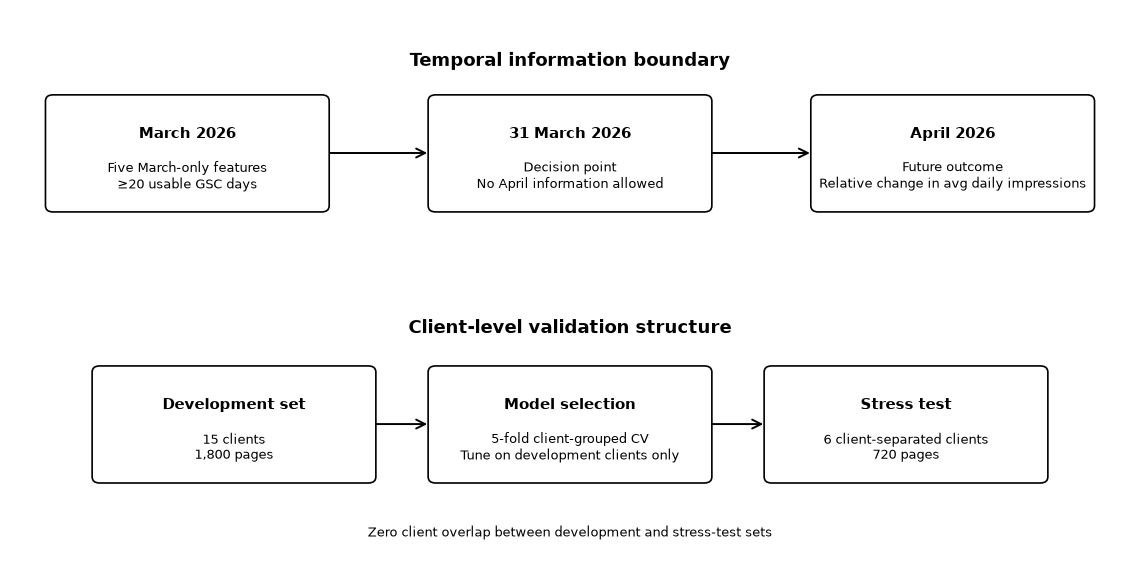

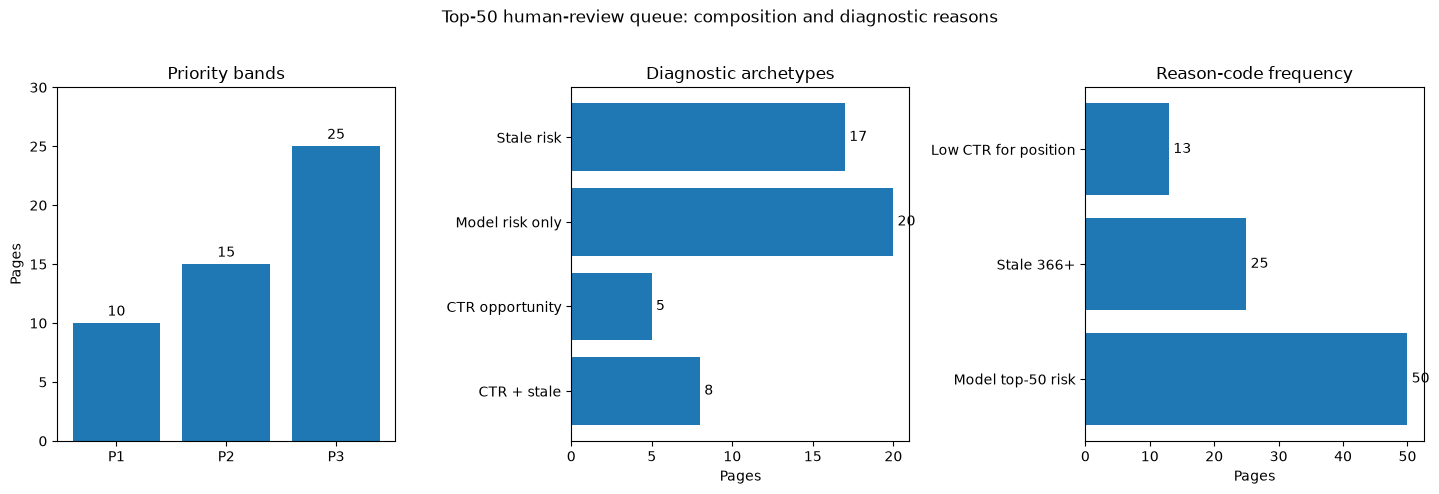

Paper artifact manifest:


,order,path,role,public_safe
0,1,work/figures/capstone_methodology_design.png,"decision point, temporal information boundary,...",True
1,2,work/figures/capstone_model_vs_baseline.png,model-versus-baseline comparison across develo...,True
2,3,work/figures/capstone_action_playbook.png,top-50 human-review queue composition,True



Required artifacts present: 4 / 4
Manifest: /home/runner/work/flyrank-ml-internship/flyrank-ml-internship/work/outputs/capstone_artifact_manifest.json


In [7]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

figures_dir = repo_path("work/figures")
figures_dir.mkdir(parents=True, exist_ok=True)
outputs_dir = repo_path("work/outputs")
outputs_dir.mkdir(parents=True, exist_ok=True)

# -------------------------------------------------------------------
# FIGURE 1 — decision point + validation design
# -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11.5, 5.8))
ax.set_xlim(0, 12)
ax.set_ylim(0, 7)
ax.axis("off")

def add_box(ax, x, y, w, h, title, body):
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.02,rounding_size=0.08",
        linewidth=1.2,
        facecolor="white",
        edgecolor="black",
    )
    ax.add_patch(box)
    ax.text(x + w/2, y + h*0.67, title, ha="center", va="center", fontsize=11, fontweight="bold")
    ax.text(x + w/2, y + h*0.30, body, ha="center", va="center", fontsize=9, wrap=True)

# Temporal contract
add_box(ax, 0.4, 4.45, 3.0, 1.45, "March 2026", "Five March-only features\n≥20 usable GSC days")
add_box(ax, 4.5, 4.45, 3.0, 1.45, "31 March 2026", "Decision point\nNo April information allowed")
add_box(ax, 8.6, 4.45, 3.0, 1.45, "April 2026", "Future outcome\nRelative change in avg daily impressions")

for x1, x2 in [(3.4, 4.5), (7.5, 8.6)]:
    ax.add_patch(FancyArrowPatch((x1, 5.18), (x2, 5.18), arrowstyle="->", mutation_scale=16, linewidth=1.4))

ax.text(6.0, 6.35, "Temporal information boundary", ha="center", va="center", fontsize=13, fontweight="bold")

# Validation structure
add_box(ax, 0.9, 1.0, 3.0, 1.45, "Development set", "15 clients\n1,800 pages")
add_box(ax, 4.5, 1.0, 3.0, 1.45, "Model selection", "5-fold client-grouped CV\nTune on development clients only")
add_box(ax, 8.1, 1.0, 3.0, 1.45, "Stress test", "6 stress-test clients\n720 pages")

for x1, x2 in [(3.9, 4.5), (7.5, 8.1)]:
    ax.add_patch(FancyArrowPatch((x1, 1.73), (x2, 1.73), arrowstyle="->", mutation_scale=16, linewidth=1.4))

ax.text(6.0, 2.95, "Client-level validation structure", ha="center", va="center", fontsize=13, fontweight="bold")
ax.text(
    6.0, 0.35,
    "Zero client overlap between development and stress-test sets",
    ha="center", va="center", fontsize=9
)

methodology_figure = figures_dir / "capstone_methodology_design.png"
fig.tight_layout()
fig.savefig(methodology_figure, dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

# -------------------------------------------------------------------
# FIGURE 2 already generated in Results
# -------------------------------------------------------------------
results_figure = figures_dir / "capstone_model_vs_baseline.png"
assert results_figure.exists(), f"Missing required Results figure: {results_figure}"

# -------------------------------------------------------------------
# FIGURE 3 — action playbook composition
# -------------------------------------------------------------------
priority_counts = paper_playbook["queue"]["review_priority_counts"]
archetype_counts = paper_playbook["queue"]["archetype_counts"]
reason_counts = paper_playbook["queue"]["reason_code_counts"]

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.8))

# Priority bands
priority_labels = ["P1", "P2", "P3"]
priority_values = [priority_counts[k] for k in priority_labels]
bars = axes[0].bar(priority_labels, priority_values)
axes[0].set_title("Priority bands")
axes[0].set_ylabel("Pages")
axes[0].set_ylim(0, max(priority_values) + 5)
axes[0].bar_label(bars, padding=3)

# Archetypes
arch_labels = ["CTR + stale", "CTR opportunity", "Model risk only", "Stale risk"]
arch_keys = ["CTR_AND_STALE", "CTR_OPPORTUNITY", "MODEL_RISK_ONLY", "STALE_RISK"]
arch_values = [archetype_counts[k] for k in arch_keys]
bars = axes[1].barh(arch_labels, arch_values)
axes[1].set_title("Diagnostic archetypes")
axes[1].set_xlabel("Pages")
axes[1].bar_label(bars, padding=3)

# Reason codes — counts can overlap
reason_labels = ["Model top-50 risk", "Stale 366+", "Low CTR for position"]
reason_keys = ["MODEL_TOP50_RISK", "STALE_366_PLUS", "LOW_CTR_FOR_POSITION"]
reason_values = [reason_counts[k] for k in reason_keys]
bars = axes[2].barh(reason_labels, reason_values)
axes[2].set_title("Reason-code frequency")
axes[2].set_xlabel("Pages")
axes[2].bar_label(bars, padding=3)

fig.suptitle("Top-50 human-review queue: composition and diagnostic reasons", y=1.02)
fig.tight_layout()

playbook_figure = figures_dir / "capstone_action_playbook.png"
fig.savefig(playbook_figure, dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

# -------------------------------------------------------------------
# Public paper artifact manifest
# -------------------------------------------------------------------
artifact_manifest = {
    "assignment": 9,
    "paper_figures": [
        {
            "order": 1,
            "path": "work/figures/capstone_methodology_design.png",
            "role": "decision point, temporal information boundary, and client-level validation design",
            "caption": (
                "March-only features are fixed at the 31 March 2026 decision point; "
                "April provides the future outcome. Model selection occurs on 15 development "
                "clients, followed by a six-client client-separated stress test."
            ),
            "public_safe": True,
        },
        {
            "order": 2,
            "path": "work/figures/capstone_model_vs_baseline.png",
            "role": "model-versus-baseline comparison across development CV and held-out client stress test",
            "caption": (
                "Learned components improve over frozen baselines during grouped development CV, "
                "but on six unseen clients only regression retains a modest improvement; "
                "classification and ranking do not beat baseline."
            ),
            "public_safe": True,
        },
        {
            "order": 3,
            "path": "work/figures/capstone_action_playbook.png",
            "role": "top-50 human-review queue composition",
            "caption": (
                "The research queue is divided into priority bands, diagnostic archetypes and "
                "transparent reason codes. Counts describe review composition, not intervention effects."
            ),
            "public_safe": True,
        },
    ],
    "public_safety": {
        "client_ids_in_figures": False,
        "content_ids_in_figures": False,
        "domains_or_urls_in_figures": False,
        "raw_queries_in_figures": False,
        "causal_action_claims_in_figures": False,
    },
}

manifest_path = outputs_dir / "capstone_artifact_manifest.json"
with open(manifest_path, "w", encoding="utf-8") as fh:
    json.dump(artifact_manifest, fh, indent=2)

required_paths = [
    methodology_figure,
    results_figure,
    playbook_figure,
    manifest_path,
]
missing = [str(p) for p in required_paths if not p.exists()]
assert not missing, f"Missing paper artifacts: {missing}"
assert len(artifact_manifest["paper_figures"]) == 3
assert all(item["public_safe"] for item in artifact_manifest["paper_figures"])
assert not any(artifact_manifest["public_safety"].values())

artifact_table = pd.DataFrame(artifact_manifest["paper_figures"])[
    ["order", "path", "role", "public_safe"]
]

print("Paper artifact manifest:")
display(artifact_table)
print("\nRequired artifacts present:", len(required_paths), "/", len(required_paths))
print("Manifest:", manifest_path)


## 8. Reproducibility

The public repository is the reproducibility record for this paper:

- Repository: https://github.com/NiknaxTheGreek/flyrank-ml-internship
- Capstone notebook: `work/notebooks/capstone.ipynb`
- Data contract and feature selection: `work/notebooks/w03_data_contract.ipynb`
- Frozen baselines: `work/notebooks/w04_baseline_score.ipynb`
- Learned models and tuning: `work/notebooks/w05_model.ipynb`
- Validation / leakage audit: `work/notebooks/w06_validation_audit.ipynb`
- Action playbook: `work/notebooks/w07_action_playbook.ipynb`

The frozen outer split is `GroupShuffleSplit(test_size=0.25, random_state=42)` by `client_hash_id`: 1,800 development pages from 15 clients and 720 stress-test pages from 6 clients, with zero client overlap. Model selection uses five-fold client-grouped cross-validation on the development clients only.

The active feature contract is exactly `aggregate_ctr`, `median_position`, `position_slope_per_day`, `position_iqr`, and `content_age_days`. March 2026 supplies predictors up to the 31 March decision point; April 2026 supplies the future outcome.

Assignments that rebuild directly from the gated warehouse require approved access to `FlyRank/internship-warehouse` and an `HF_TOKEN`. The capstone itself reruns from committed public-safe receipts and figures, so its reported evidence can be inspected without exposing private client-level data.

Cross-assignment consistency is enforced by `work/methodology_consistency_check.py`, which verifies the population, split, features, targets, baselines, model results, validation results, queue construction and guardrails against the committed artifacts.

## 9. Acknowledgments & data credit

**[Built on the FlyRank ML Internship dataset](https://flyrank.ai).**

The analysis uses the pseudonymized FlyRank internship warehouse release documented in this repository. The public paper reports only aggregate, pseudonymized results and does not expose client names, domains, URLs, page titles, raw search queries, credentials or other private identifiers.

The project is an educational/research proof of concept for human decision support. It does not claim access to Google's ranking algorithm and does not estimate causal effects of content interventions.

In [8]:
paper_contract = {
    "title": "Which Content Pages Should Be Reviewed First?",
    "abstract_sentences": 5,
    "canonical_sections": 9,
    "decision_cutoff": "2026-03-31",
    "random_state": 42,
    "active_features": expected_features,
    "repo_url": "https://github.com/NiknaxTheGreek/flyrank-ml-internship",
    "data_credit_url": "https://flyrank.ai",
    "data_credit_phrase": "Built on the FlyRank ML Internship dataset",
}

abstract_text = """This study investigates whether information available before a content-review decision can identify pages at risk of future search-performance decline and, more importantly, determine which pages should receive limited human attention first. From the pseudonymized FlyRank internship warehouse, a balanced proof-of-concept cohort of 2,520 pages across 21 clients was constructed through exposure-based stratification, while candidate predictors were grouped by behavioral role and reduced to five leakage-safe March 2026 features—aggregate_ctr, median_position, position_slope_per_day, position_iqr, and content_age_days—without using April outcomes for selection. Classification estimates whether future decline occurs, signed regression estimates the direction and magnitude of future impression change, and negative predicted change is converted to decline severity and combined with classification risk to rank a top-50 review queue; independent CTR and freshness diagnostics then attach transparent reason codes and rule-based action archetypes so a reviewer can understand why a page was surfaced. The pipeline showed useful signal during development validation that kept clients separated, but a six-client stress test exposed limited transfer: regression retained a modest improvement over its frozen baseline, while classification and the final ranking did not. The contribution is therefore a human-review decision-support framework—not an automated intervention system—that connects risk estimation, change estimation, prioritization and diagnostic guidance while requiring fresh client-level validation before broader operational use."""

assert paper_contract["active_features"] == leakage_audit["active_features"]
assert split_manifest["random_state"] == paper_contract["random_state"]
assert split_manifest["client_overlap"] == []
assert paper_contract["canonical_sections"] == 9
assert abstract_text.count(". ") + int(abstract_text.endswith(".")) == 5
assert paper_contract["data_credit_phrase"] == "Built on the FlyRank ML Internship dataset"

print("Paper wrapper contract verified.")
print("Title:", paper_contract["title"])
print("Abstract sentences:", paper_contract["abstract_sentences"])
print("Canonical deployed sections:", paper_contract["canonical_sections"])
print("Data credit:", paper_contract["data_credit_phrase"], "->", paper_contract["data_credit_url"])

Paper wrapper contract verified.
Title: Which Content Pages Should Be Reviewed First?
Abstract sentences: 5
Canonical deployed sections: 9
Data credit: Built on the FlyRank ML Internship dataset -> https://flyrank.ai


## Self-check

Before you submit, confirm each line honestly:

- [x] Every Assignment 9 paper section is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors
- [x] No client names, client URLs/domains, or private queries are exposed in the public paper
- [x] Claims use careful language: observed, measured, directional, decision-support
- [x] Capstone work is committed under `work/notebooks/`
- [x] The deployed paper has all **9 canonical sections**, including the **Abstract** and **Acknowledgments & data credit** linking to https://flyrank.ai
- [x] The exact deployed URL is the only line in `submission/paper_url.txt`
- [x] **Assignment 10 / ML-12:** 5-minute demo outline + social-post cut + 3-sentence employer-facing summary added


## Assignment 10 — 5-minute demo outline

### 0:00–0:45 — Question

FlyRank's content-review problem is an allocation problem: a content or SEO team cannot inspect every page, so which pages should receive limited human attention first?

This capstone asks whether information available by a fixed decision point can identify future search-performance decline and turn that evidence into a transparent top-50 human-review queue.

### 0:45–2:00 — Method

The proof of concept uses **2,520 pseudonymized pages across 21 clients**. March 2026 supplies the five leakage-safe model features — `aggregate_ctr`, `median_position`, `position_slope_per_day`, `position_iqr`, and `content_age_days` — and April 2026 supplies the future outcome.

The system progresses through three standard tasks: **classification** estimates whether decline occurs, **signed regression** estimates the direction and magnitude of future impression change, and **ranking** combines predicted risk and decline severity to prioritize a fixed top-50 review queue.

Validation is client-separated: **15 clients / 1,800 pages** are used for model development with five-fold client-grouped cross-validation, while **6 clients / 720 pages** form a client-separated stress-test set. Every learned component is compared with a frozen transparent baseline.

### 2:00–3:15 — One chart

Show **`work/figures/capstone_model_vs_baseline.png`**.

The chart compares the learned system with the frozen baselines in two layers. During grouped development validation, all three learned components improved on baseline: classification ROC-AUC **0.665 vs 0.500**, regression RMSE **0.806 vs 0.852**, and ranking Precision@50 **0.872 vs 0.824**.

Then move to the six-client stress-test side of the same chart. This is the key transition: the development gains did not transfer consistently to unseen clients.

### 3:15–4:15 — One honest result

On the six-client stress test, the learned ranking achieved **Precision@50 = 0.360**, below the frozen rule baseline of **0.480**. Classification was also effectively at chance level (**ROC-AUC 0.494 vs 0.500 baseline**), while regression retained only a modest improvement (**RMSE 1.379 vs 1.431 baseline**).

The main finding is therefore not that machine learning universally beat the rule. It is that performance was **validation-sensitive**, and client-separated stress testing exposed a transfer problem that development validation alone would have hidden.

### 4:15–5:00 — One recommendation

Use the current system as a **guarded human-review research tool, not an automated content-action system**. Keep the transparent baseline as an explicit comparator, use the ranked queue and reason codes to support analyst review, and require fresh client-level validation before broader operational use.

The practical next step is to collect reviewer feedback and new-client evidence, then only promote the learned ranking if it consistently beats the frozen baseline on the operational metric, Precision@50.


## Assignment 10 — shareable cuts

### Social post

I built a leakage-safe content-review prioritization POC for FlyRank using classification, signed regression and ranking to decide which pages should enter a limited human-review queue first. The analysis used 2,520 pseudonymized pages across 21 clients, five March-only features, client-grouped development validation and a six-client stress test. Development results looked promising, but the unseen-client test showed why honest validation matters: the learned ranking fell to **Precision@50 = 0.360** versus a **0.480** transparent rule baseline, so the final system is framed as human decision support rather than automated intervention. The project, methodology and results are here: https://flyrank-content-review-capstone.onrender.com

### Employer-facing summary

I built a leakage-safe ML decision-support pipeline for FlyRank that combines classification, signed regression, ranking and reason-coded human review to prioritize which content pages should be reviewed first. It used a balanced proof-of-concept cohort of **2,520 pseudonymized pages across 21 clients**, five March 2026 features and April 2026 outcomes, with client-separated grouped validation and a six-client stress test. The learned components improved on their baselines during grouped development validation, but on unseen clients only regression retained a modest improvement while classification and ranking did not beat their transparent baselines, showing why revalidation is required before broader operational use.
